## **Качественный анализ движения оси волчка в случае Лагранжа уравнения динамически симметричного тела**

#### **Интеграл энергии**

Так как $K^z = const$, $Cr = const$, а интеграл энергии принимает вид

$$E = \frac{1}{2}(A(p^2 + q^2) + Cr^2) + mgl cos \theta = const$$

Из кинематических уравнений Эйлера

$$E = \frac{1}{2}A(\dot \theta^2 + \dot \psi^2 sin^2 \theta) + \frac{1}{2}Cr^2 + mgl cos \theta = const$$

$$E' = A(\dot \theta^2 + \dot \psi^2 sin^2 \theta) + 2 mgl cos \theta = const$$

#### **Момент импульса**

Проекция момента импульса на вертикаль:

$$K^z = \langle \mathbf{K}, \mathbf{e^z}\rangle$$

Тогда, используя кинематические уравнения Эйлера, получим

$$K^z = Ap sin \theta  sin \varphi + Aq sin \theta cos \varphi + Cr cos \theta = A \dot \psi sin^2 \theta + Cr cos \theta$$

$$\dot \psi = \frac{K^z - Cr cos \theta}{A sin^2 \theta}$$

#### **Дифференциальное уравнение относительно $cos \theta$**

Подставим это выражение в интеграл энергии

$$E' = A \dot \theta^2 + \frac{(K^z - Cr cos \theta)^2}{A sin^2 \theta} + 2 mgl cos \theta$$

Произведём замену $s = cos \theta$ и подставим:

$$A^2 \dot s^2 + (K^z -Crs)^2 + A(2mgls - E')(1-s^2) = 0$$

In [32]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.animation as animation

from scipy.integrate import solve_ivp
from scipy.optimize import fsolve

In [33]:
A = 1.0
mgl = 0.2
Kz = 0.7
Cr = 1.5

def energy(theta, theta_dot, psi_dot):
    """Интеграл энергии"""
    return A * (theta_dot**2 + psi_dot**2 * np.sin(theta)**2) + 2 * mgl * np.cos(theta)

def precession(theta):
    """Угловая скорость прецессии"""
    return (Kz - Cr * np.cos(theta)) / (A * np.sin(theta)**2)

theta_0 = 0
theta_dot_0 = 0
psi_dot_0 = 0

def s_equation(s):
    """Уравнение f(s)"""
    E = energy(theta_0, theta_dot_0, psi_dot_0)
    return -(Kz - Cr * s)**2 / A**2 - (2 * mgl * s - E) * (1 - s**2) / A

def find_roots():
    """Поиск корней f(s) на [-1, 1]"""
    roots = []
    for s_guess in np.linspace(-1, 1, 50):
        try:
            s_root = fsolve(s_equation, s_guess)[0]
            if -1 <= s_root <= 1 and abs(s_equation(s_root)) < 1e-10:
                roots.append(s_root)
        except:
            continue
    
    return np.unique(np.round(roots, 8))

In [34]:
def sphere(ax):
    """Отрисовка сферы"""
    phi = np.linspace(0, 2*np.pi, 50)
    theta_sphere = np.linspace(0, np.pi, 25)
    phi_grid, theta_grid = np.meshgrid(phi, theta_sphere)

    X_sphere = np.sin(theta_grid) * np.cos(phi_grid)
    Y_sphere = np.sin(theta_grid) * np.sin(phi_grid)
    Z_sphere = np.cos(theta_grid)
    ax.plot_surface(X_sphere, Y_sphere, Z_sphere, color='lightblue', alpha=0.2)

def axis_limits(ax, roots, color):
    """Граничные занчения косинуса угла нутации (точки поворота)"""
    theta_circle_1, theta_circle_2 = np.acos(roots)
    circle_phi = np.linspace(0, 2 * np.pi, 100)

    x_circle_1 = np.sin(theta_circle_1) * np.cos(circle_phi)
    y_circle_1 = np.sin(theta_circle_1) * np.sin(circle_phi)
    z_circle_1 = np.cos(theta_circle_1) * np.ones_like(circle_phi)
    ax.plot(x_circle_1, y_circle_1, z_circle_1, color, linewidth=1, label=f'θ = {theta_circle_1:.2f}')

    x_circle_2 = np.sin(theta_circle_2) * np.cos(circle_phi)
    y_circle_2 = np.sin(theta_circle_2) * np.sin(circle_phi)
    z_circle_2 = np.cos(theta_circle_2) * np.ones_like(circle_phi)
    ax.plot(x_circle_2, y_circle_2, z_circle_2, color, linewidth=1, label=f'θ = {theta_circle_2:.2f}')

In [35]:
def solve_segments(E, theta_0, s_min, s_max, total_time=30, tol=1e-3):
    """Численное решение ДУ"""
    t_segments = []
    s_segments = []
    t_current = 0
    direction = 1
    segment_count = 0
    max_segments = 23
    
    s_current = np.cos(theta_0)
    if abs(np.cos(theta_0) - s_min) < abs(np.cos(theta_0) - s_max):
        s_current += tol
    else:
        s_current -= tol

    while t_current < total_time and segment_count < max_segments:
        if direction > 0:
            target = s_max - tol
        else:
            target = s_min + tol
            
        def dsdt(t, s):
            rhs = - (Kz - Cr*s)**2 - A*(2*mgl*s - E)*(1 - s**2)
            return direction * np.sqrt(np.maximum(rhs, 0))
        
        t_end = t_current + 10
        
        try:
            sol = solve_ivp(dsdt, [t_current, t_end], [s_current], 
                           method='RK45', rtol=1e-8, atol=1e-10, dense_output=True)
            
            t_fine = np.linspace(t_current, min(t_current + 10, total_time), 1000)
            s_fine = sol.sol(t_fine)[0]
            
            if direction > 0:
                cross_idx = np.where(s_fine >= target)[0]
            else:
                cross_idx = np.where(s_fine <= target)[0]
            
            if len(cross_idx) > 0:
                idx = cross_idx[0]
                t_segment = t_fine[:idx+1]
                s_segment = s_fine[:idx+1]
                t_current = t_fine[idx]
                s_current = s_fine[idx]
            else:
                t_segment = t_fine
                s_segment = s_fine
                t_current = t_fine[-1]
                s_current = s_fine[-1]
            
            t_segments.append(t_segment)
            s_segments.append(s_segment)
            direction *= -1
            segment_count += 1
            
        except Exception as e:
            print(f"Ошибка при решении: {e}")
            break
    
    if t_segments:
        t_all = np.concatenate(t_segments)
        s_all = np.concatenate(s_segments)
        return t_all, s_all
    else:
        return np.array([]), np.array([])

#### **Случай 1**:

$\theta(0) = \pi / 3.7$,  $\dot \theta(0) = 0$,  $\dot \psi(0) < 0$

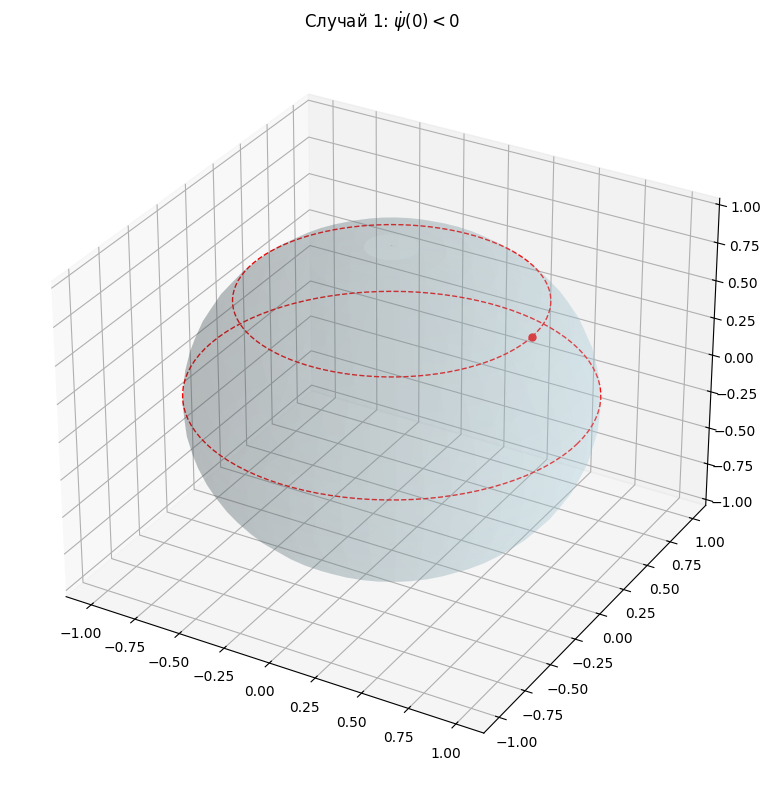

In [36]:
theta_0 = np.pi / 3.7
psi_dot_0 = precession(theta_0)
s_min1, s_max1 =  find_roots()
E1 = energy(theta_0, theta_dot_0, psi_dot_0)
t_values1, s_values1 = solve_segments(E1, theta_0, s_min1, s_max1, 100)

fig = plt.figure(figsize=(16, 8))

ax1 = fig.add_subplot(111, projection='3d')
t1, theta1 = t_values1, np.acos(s_values1)
psi1 = np.zeros_like(t1)
for i in range(1, len(t1)):
    dt = t1[i] - t1[i-1]
    theta_avg = (theta1[i-1] + theta1[i]) / 2
    psi1[i] = psi1[i-1] + precession(theta_avg) * dt

x1 = np.sin(theta1) * np.cos(psi1)
y1 = np.sin(theta1) * np.sin(psi1)
z1 = np.cos(theta1)

sphere(ax1)
axis_limits(ax1, find_roots(), 'r--')

point1, = ax1.plot([], [], [], 'ro', markersize=5)
traj1, = ax1.plot([], [], [], 'r-', alpha=0.7, linewidth=2)
ax1.set_title(r'$\text{Случай 1: } \dot \psi(0) < 0$')

def animate1(i):
    idx = i * 10
    
    if idx < len(x1):
        point1.set_data([x1[idx]], [y1[idx]])
        point1.set_3d_properties([z1[idx]])
        traj1.set_data(x1[:idx+1], y1[:idx+1])
        traj1.set_3d_properties(z1[:idx+1])
    
    return point1, traj1

frames = len(x1) // 10
ani = animation.FuncAnimation(fig, animate1, frames=frames, 
                              interval=50, blit=True)
plt.tight_layout()
plt.show()
ani.save('less_then_zero.gif', writer='pillow', fps=30)

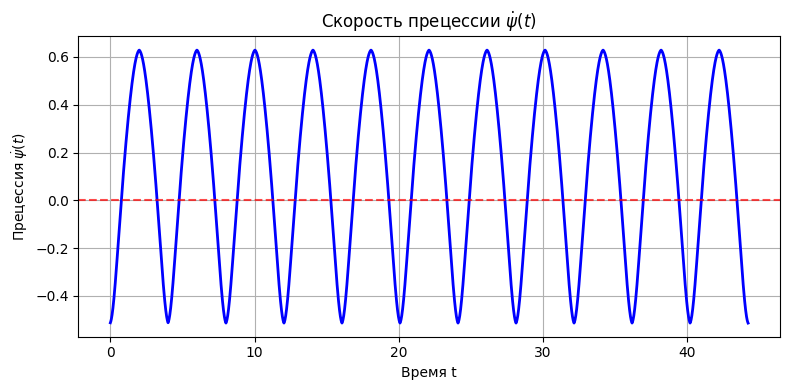

In [37]:
plt.figure(figsize=(8, 4))
plt.plot(t_values1, precession(np.acos(s_values1)), 'b-', linewidth=2, label='s(t)')
plt.axhline(0, color='r', linestyle='--', alpha=0.7)
plt.xlabel('Время t')
plt.ylabel(r'$\text{Прецессия }\dot \psi(t)$')
plt.title(r'$ \text{Скорость прецессии } \dot \psi(t)$')
plt.grid(True)
plt.tight_layout()
plt.show()

#### **Случай 2**:

$\theta(0) = \pi / 2.2$,  $\dot \theta(0) = 0$,  $\dot \psi(0) > 0$

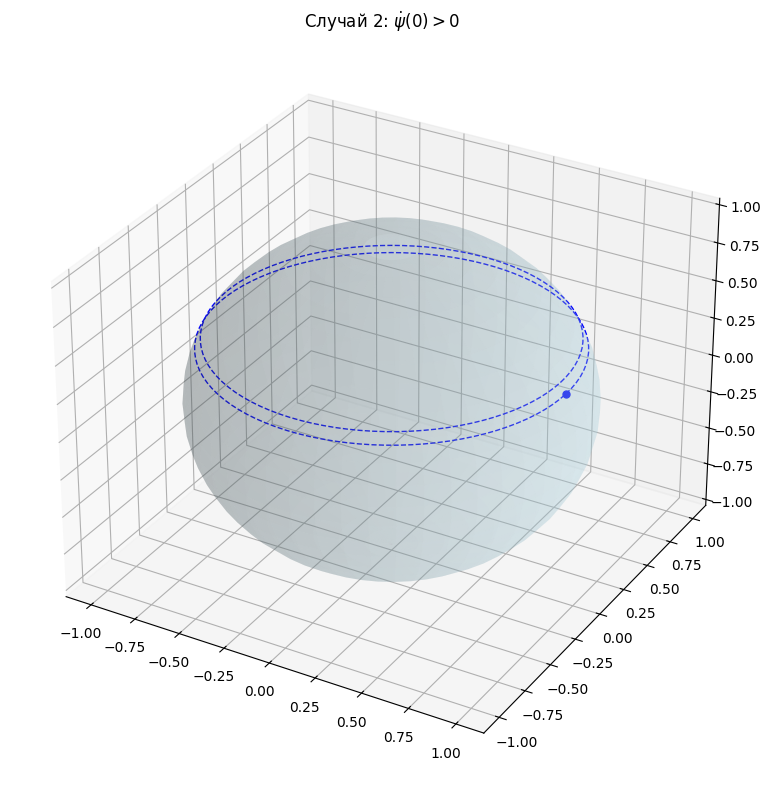

In [38]:
theta_0 = np.pi / 2.6
psi_dot_0 = precession(theta_0)
s_min2, s_max2 =  find_roots()
E2 = energy(theta_0, theta_dot_0, psi_dot_0)
t_values2, s_values2 = solve_segments(E2, theta_0, s_min2, s_max2, 100)

fig = plt.figure(figsize=(16, 8))

ax2 = fig.add_subplot(111, projection='3d')
t2, theta2 = t_values2, np.acos(s_values2)
psi2 = np.zeros_like(t2)
for i in range(1, len(t2)):
    dt = t2[i] - t2[i-1]
    theta_avg = (theta2[i-1] + theta2[i]) / 2
    psi2[i] = psi2[i-1] + precession(theta_avg) * dt

x2 = np.sin(theta2) * np.cos(psi2)
y2 = np.sin(theta2) * np.sin(psi2)
z2 = np.cos(theta2)

sphere(ax2)
axis_limits(ax2, find_roots(), 'b--')

point2, = ax2.plot([], [], [], 'bo', markersize=5)
traj2, = ax2.plot([], [], [], 'b-', alpha=0.7, linewidth=2)
ax2.set_title(r'$\text{Случай 2: } \dot \psi(0) > 0$')

def animate1(i):
    idx = i * 10
    
    if idx < len(x2):
        point2.set_data([x2[idx]], [y2[idx]])
        point2.set_3d_properties([z2[idx]])
        traj2.set_data(x2[:idx+1], y2[:idx+1])
        traj2.set_3d_properties(z2[:idx+1])
    
    return point2, traj2

frames = len(x2) // 10
ani = animation.FuncAnimation(fig, animate1, frames=frames, 
                              interval=50, blit=True)
plt.tight_layout()
plt.show()
ani.save('greater_then_zero.gif', writer='pillow', fps=30)

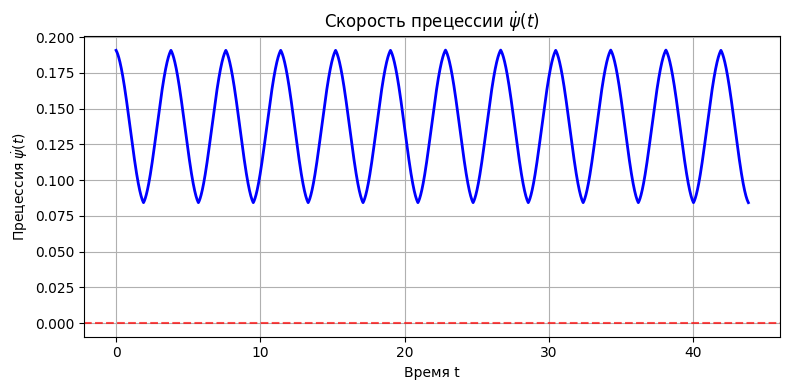

In [39]:
plt.figure(figsize=(8, 4))
plt.plot(t_values2, precession(np.acos(s_values2)), 'b-', linewidth=2, label='s(t)')
plt.axhline(0, color='r', linestyle='--', alpha=0.7)
plt.xlabel('Время t')
plt.ylabel(r'$\text{Прецессия }\dot \psi(t)$')
plt.title(r'$ \text{Скорость прецессии } \dot \psi(t)$')
plt.grid(True)
plt.tight_layout()
plt.show()

#### **Случай 3**:

$\theta(0) = arccos\frac{K^z}{Cr}$,  $\dot \theta(0) = 0$,  $\dot \psi(0) = 0$

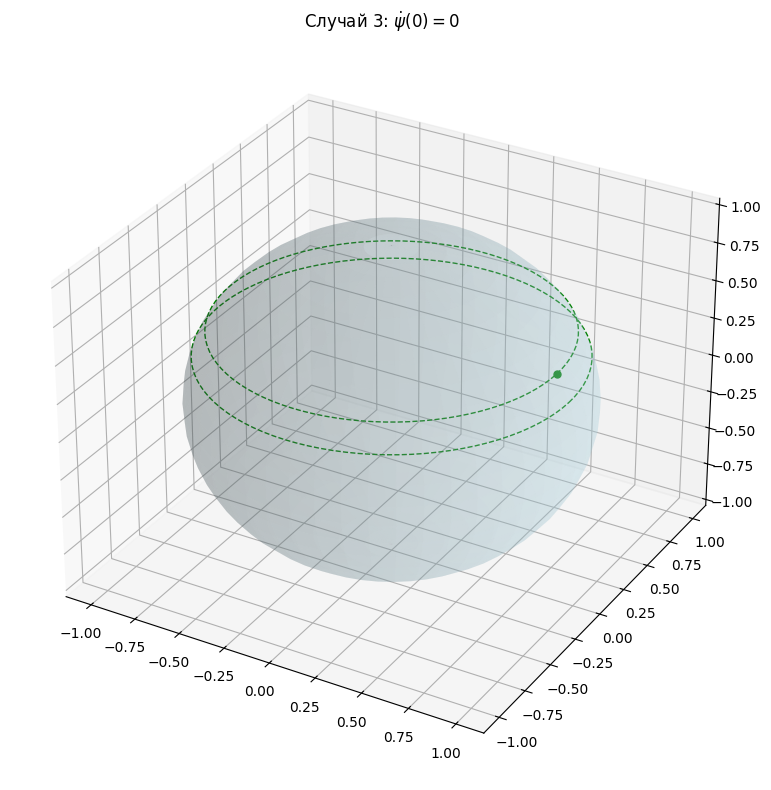

In [40]:
theta_0 = np.acos(Kz / Cr)
psi_dot_0 = precession(theta_0)
s_min3, s_max3 =  find_roots()
E3 = energy(theta_0, theta_dot_0, psi_dot_0)
t_values3, s_values3 = solve_segments(E3, theta_0, s_min3, s_max3, 100)

fig = plt.figure(figsize=(8, 8))

ax3 = fig.add_subplot(111, projection='3d')
t3, theta3 = t_values3, np.acos(s_values3)
psi3 = np.zeros_like(t3)
for i in range(1, len(t1)):
    dt = t3[i] - t3[i-1]
    theta_avg = (theta3[i-1] + theta3[i]) / 2
    psi3[i] = psi3[i-1] + precession(theta_avg) * dt

x3 = np.sin(theta3) * np.cos(psi3)
y3 = np.sin(theta3) * np.sin(psi3)
z3 = np.cos(theta3)

sphere(ax3)
axis_limits(ax3, find_roots(), 'g--')

point3, = ax3.plot([], [], [], 'go', markersize=5)
traj3, = ax3.plot([], [], [], 'g-', alpha=0.7, linewidth=2)
ax3.set_title(r'$\text{Случай 3: } \dot \psi(0) = 0$')

def animate3(i):
    idx = i * 10
    
    if idx < len(x1):
        point3.set_data([x3[idx]], [y3[idx]])
        point3.set_3d_properties([z3[idx]])
        traj3.set_data(x3[:idx+1], y3[:idx+1])
        traj3.set_3d_properties(z3[:idx+1])

    return point3, traj3

frames = len(x3) // 10
ani = animation.FuncAnimation(fig, animate3, frames=frames, 
                              interval=50, blit=True)
plt.tight_layout()
plt.show()
ani.save('eq_zero.gif', writer='pillow', fps=30)

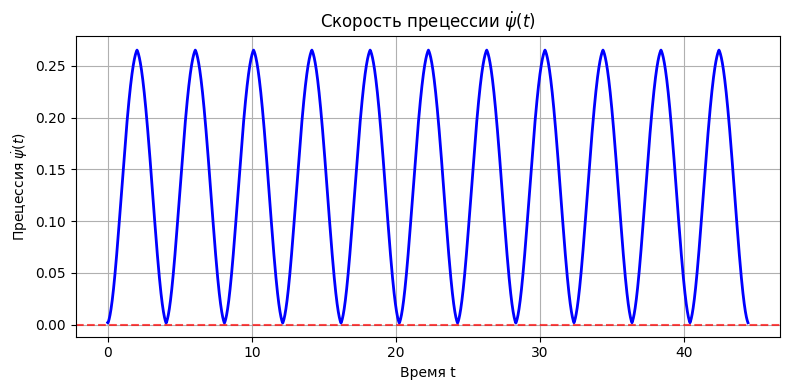

In [41]:
plt.figure(figsize=(8, 4))
plt.plot(t_values3, precession(np.acos(s_values3)), 'b-', linewidth=2, label='s(t)')
plt.axhline(0, color='r', linestyle='--', alpha=0.7)
plt.xlabel('Время t')
plt.ylabel(r'$\text{Прецессия }\dot \psi(t)$')
plt.title(r'$ \text{Скорость прецессии } \dot \psi(t)$')
plt.grid(True)
plt.tight_layout()
plt.show()